# 00_routing_analysis

- Samples random non-test utterances from LibriSpeech clean 100 dataset
- STD normalize (as is done for train/val/test)
- Apply range of alpha values to each norm'ed utterance
- Compute f_c per clipped example
     - f_c defined here as fraction of clipped samples
     - f_c = # samples at +-alpha / total samples
- Compute PESQ (Mean Opinion Score MOS from 1 - 5) on utterances
- Compute SI-SDR (scale invariant signal to distortion ratio) on utterances
- Use above to map to an f_c threshold for which inputs will be routed untouched to output
     - For lightly distorted signals, assume NN treatment is unlikely to improve PESQ and could actually risk further degradation

In [1]:
# Imports

import json
import random
import numpy as np
import torch
import torchaudio
from pesq import pesq

import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "..")
from config import *

%matplotlib widget

In [2]:
# Constants

N_UTT = 100    # Do not exceed 231!
ALPHA_GRID = np.linspace(0.05, 0.50, 10).round(2)

In [3]:
# Helper func for SDR

def si_sdr(reference, degraded):
    alpha = (degraded * reference).sum() / (reference * reference).sum()
    signal = alpha * reference
    noise = degraded - signal
    return 10 * torch.log10((signal ** 2).sum() / (noise ** 2).sum())

In [4]:
# Load utterances and clip at prescribed levels

# Load dataset and build available talker pool
dataset = torchaudio.datasets.LIBRISPEECH(
    root=LIBRISPEECH_ROOT,
    url="train-clean-100",
    download=False
)

# Get test talker IDs
with open(TEST_OUT / "test_manifest.json") as f:
    test_manifest = json.load(f)

test_tlkrs = set(entry["tlkr_id"] for entry in test_manifest)
print(f"Loaded {len(test_tlkrs)} test talkers")
print(test_tlkrs)

# Non-test talker IDs
tlkr_to_indices = {}
for i in range(len(dataset)):
    _, sr, _, tlkr, chap, utt = dataset.get_metadata(i)
    if tlkr not in test_tlkrs:
        if tlkr not in tlkr_to_indices:
            tlkr_to_indices[tlkr] = []
        tlkr_to_indices[tlkr].append(i)
print("Non-test talker IDs found")

available_tlkrs = list(tlkr_to_indices.keys())
N_UTT = min(N_UTT, len(available_tlkrs))
print(f"Available talkers: {len(available_tlkrs)}, using {N_UTT}")

# Sample one utterance per talker without replacement
random.seed(42)
selected_tlkrs = random.sample(available_tlkrs, N_UTT)

utts = []

for i, tlkr in enumerate(selected_tlkrs):
    idx = random.choice(tlkr_to_indices[tlkr])
    wav, sr, transcript, tlkr_id, chap, utt_id = dataset[idx]
    
    if sr != FS:
        wav = torchaudio.functional.resample(wav, sr, FS)
    
    std = wav.std().clamp(min=1e-8)
    wav_norm = wav / std
    
    peak = wav_norm.abs().max()
    
    utt_dict = {"clean": wav_norm, "metadata": {"tlkr_id": tlkr_id, "utt_id": utt_id}}
    
    for alpha in ALPHA_GRID:
        threshold = float(alpha) * peak
        utt_dict[float(alpha)] = wav_norm.clamp(-threshold, threshold)
    
    utts.append(utt_dict)

    if i % 10 == 0:
        print(f"Finished {i:^4} of {N_UTT:^4}", flush=True)

print(f"Loaded {len(utts)} utterances with {len(ALPHA_GRID)} clipping levels each")

Loaded 20 test talkers
{6019, 2691, 405, 6563, 40, 1069, 6064, 1081, 1723, 446, 200, 4297, 1355, 4051, 83, 5463, 730, 118, 374, 7800}
Non-test talker IDs found
Available talkers: 231, using 100
Finished  0   of 100 
Finished  10  of 100 
Finished  20  of 100 
Finished  30  of 100 
Finished  40  of 100 
Finished  50  of 100 
Finished  60  of 100 
Finished  70  of 100 
Finished  80  of 100 
Finished  90  of 100 
Loaded 100 utterances with 10 clipping levels each


In [7]:
# Loop through all gathered utterances collecting f_c PESQ and SDR

f_c = []
psq = []
sdr = []

for i, utt in enumerate(utts):
    clean = utt["clean"]
    peak = clean.abs().max()
    
    f_c_dict = {}
    psq_dict = {}
    sdr_dict = {}
    
    for alpha in ALPHA_GRID:
        clipped = utt[float(alpha)]
        threshold = float(alpha) * peak
        
        # f_c: fraction of samples at clipping boundary
        fc = (clipped.abs() >= threshold * 0.9999).float().mean().item()
        
        # PESQ: expects 1D numpy arrays
        clean_np = clean.squeeze().numpy()
        clipped_np = clipped.squeeze().numpy()
        mos = pesq(FS, clean_np, clipped_np, 'wb')
        
        # SI-SDR
        sisdr = si_sdr(clean, clipped).item()
        
        f_c_dict[float(alpha)] = fc
        psq_dict[float(alpha)] = mos
        sdr_dict[float(alpha)] = sisdr
    
    f_c.append(f_c_dict)
    psq.append(psq_dict)
    sdr.append(sdr_dict)

    print(f"Finished {i:^4} of {N_UTT:^4}", flush=True)


print("Done computing metrics.")
    

Finished  0   of 100 
Finished  1   of 100 
Finished  2   of 100 
Finished  3   of 100 
Finished  4   of 100 
Finished  5   of 100 
Finished  6   of 100 
Finished  7   of 100 
Finished  8   of 100 
Finished  9   of 100 
Finished  10  of 100 
Finished  11  of 100 
Finished  12  of 100 
Finished  13  of 100 
Finished  14  of 100 
Finished  15  of 100 
Finished  16  of 100 
Finished  17  of 100 
Finished  18  of 100 
Finished  19  of 100 
Finished  20  of 100 
Finished  21  of 100 
Finished  22  of 100 
Finished  23  of 100 
Finished  24  of 100 
Finished  25  of 100 
Finished  26  of 100 
Finished  27  of 100 
Finished  28  of 100 
Finished  29  of 100 
Finished  30  of 100 
Finished  31  of 100 
Finished  32  of 100 
Finished  33  of 100 
Finished  34  of 100 
Finished  35  of 100 
Finished  36  of 100 
Finished  37  of 100 
Finished  38  of 100 
Finished  39  of 100 
Finished  40  of 100 
Finished  41  of 100 
Finished  42  of 100 
Finished  43  of 100 
Finished  44  of 100 
Finished  

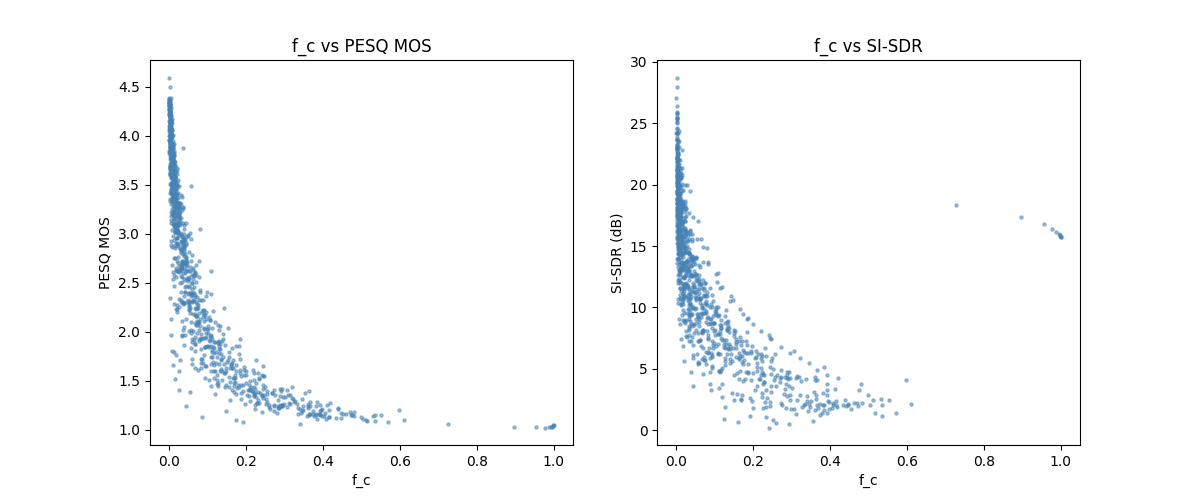

In [8]:
# Plots

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for utt_idx in range(len(utts)):
    for alpha in ALPHA_GRID:
        fc = f_c[utt_idx][float(alpha)]
        mos = psq[utt_idx][float(alpha)]
        sisdr = sdr[utt_idx][float(alpha)]
        axes[0].scatter(fc, mos, s=5, alpha=0.5, color='steelblue')
        axes[1].scatter(fc, sisdr, s=5, alpha=0.5, color='steelblue')

from scipy.optimize import curve_fit

# Flatten all fc and mos values into arrays
fc_all = np.array([f_c[i][float(a)] for i in range(len(utts)) for a in ALPHA_GRID])
mos_all = np.array([psq[i][float(a)] for i in range(len(utts)) for a in ALPHA_GRID])

axes[0].set_xlabel("f_c")
axes[0].set_ylabel("PESQ MOS")
axes[0].set_title("f_c vs PESQ MOS")

axes[1].set_xlabel("f_c")
axes[1].set_ylabel("SI-SDR (dB)")
axes[1].set_title("f_c vs SI-SDR")

plt.show()

In [9]:
# Find fc corresponding to "acceptable" MOS (3.5)

fc_thresh = 0.015

NameError: name 'fc_fit' is not defined

## Plot interpretations

- SDR plotted here just to get an idea of what the clipping range produces: will be more useful in model eval
- threshold f_c where speech can bypass declipping DNNs ~0.015. 